<a href="https://colab.research.google.com/github/kavyaaach2607-alt/Machine-Learning_Project/blob/main/Project_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Running in Google Colab - please upload credit_risk_dataset.csv


Saving credit_risk_dataset.csv to credit_risk_dataset (1).csv

1. DATASET OVERVIEW
Raw dataset: 32,581 rows x 12 columns

Missing values per column:
person_emp_length     895
loan_int_rate        3116

Duplicates removed: 165
Impossible ages (>100) set to missing: 5
Impossible employment lengths (>60) set to missing: 2
After cleaning: 32,416 rows x 12 columns

2. TARGET DISTRIBUTION - LOAN RISK CATEGORY
  Low    :  65.1%   (21,090 applicants)
  Medium :  31.0%   (10,058 applicants)
  High   :   3.9%   (1,268 applicants)

3. EXPLORATORY DATA ANALYSIS


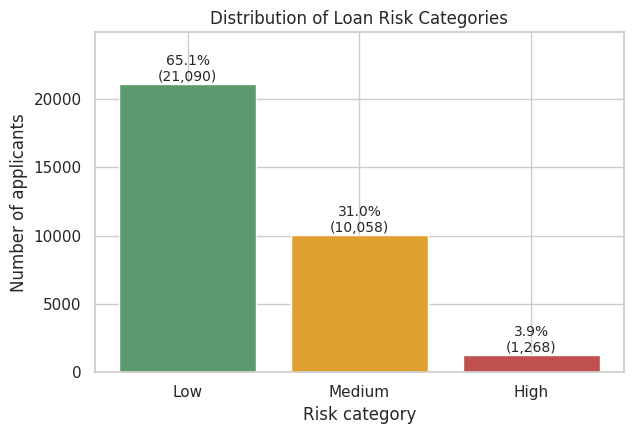

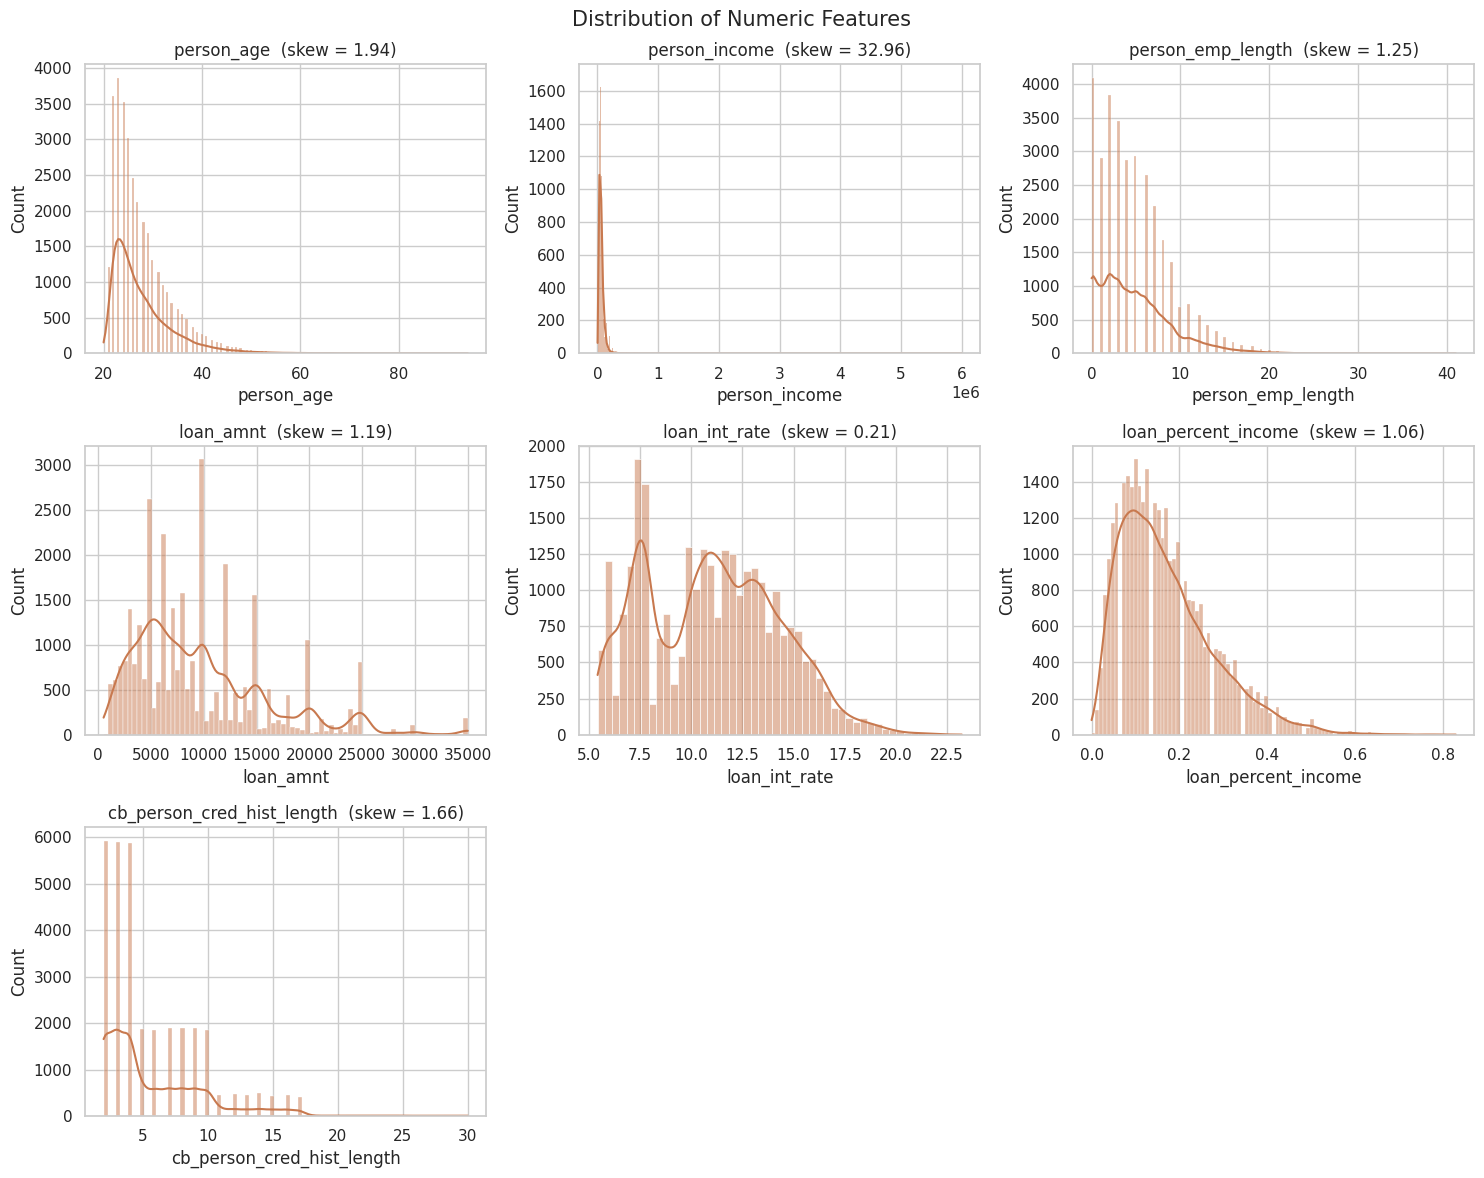

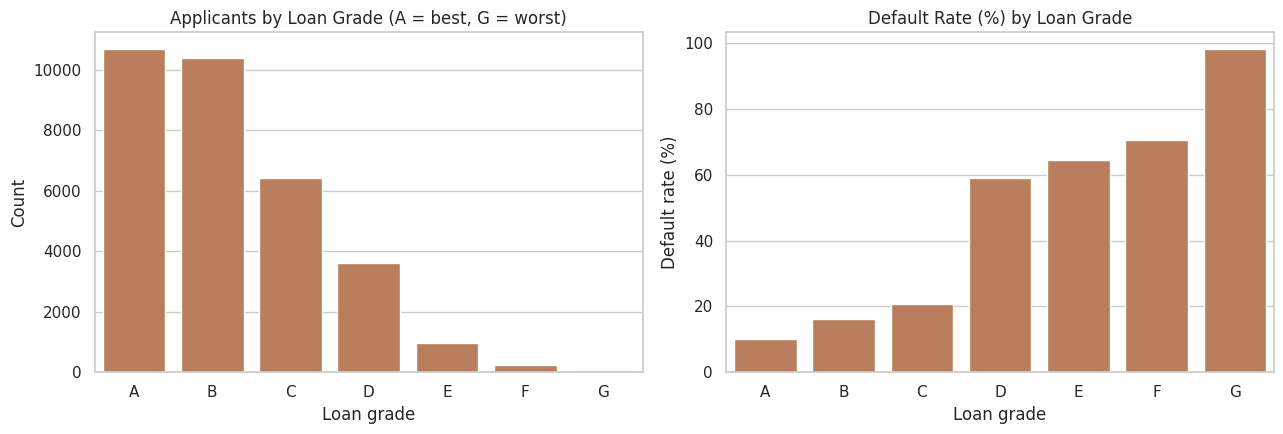

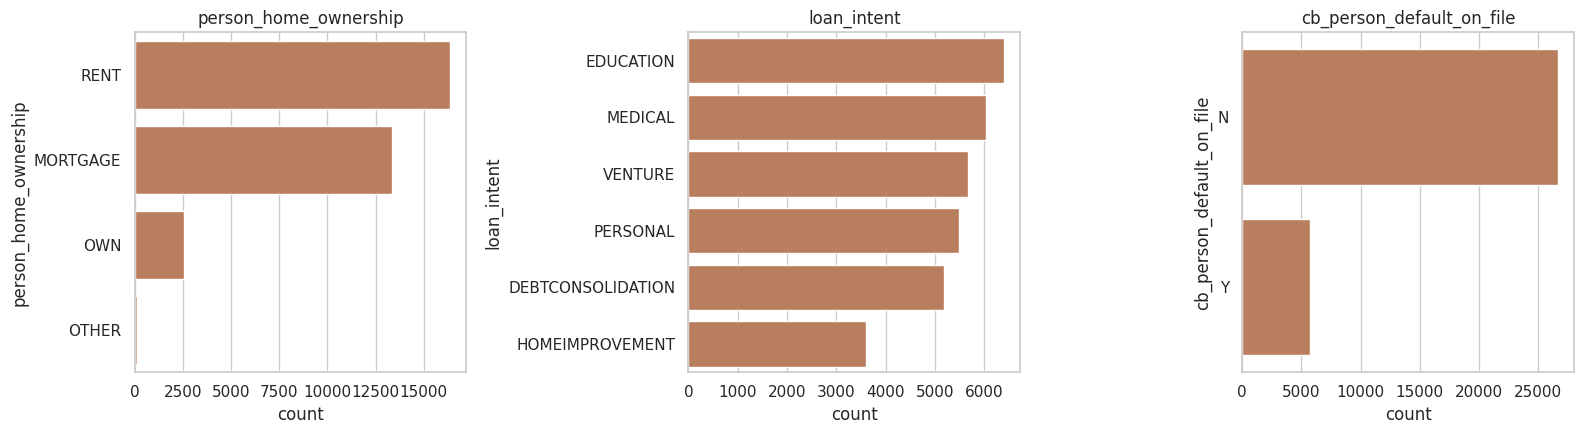

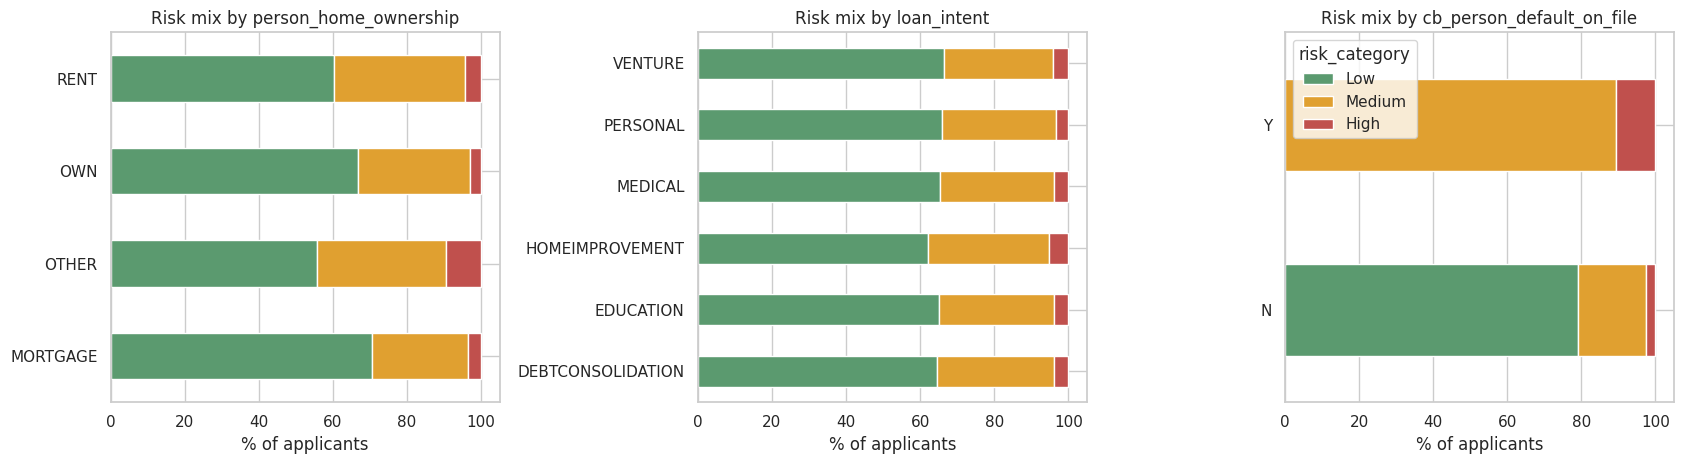

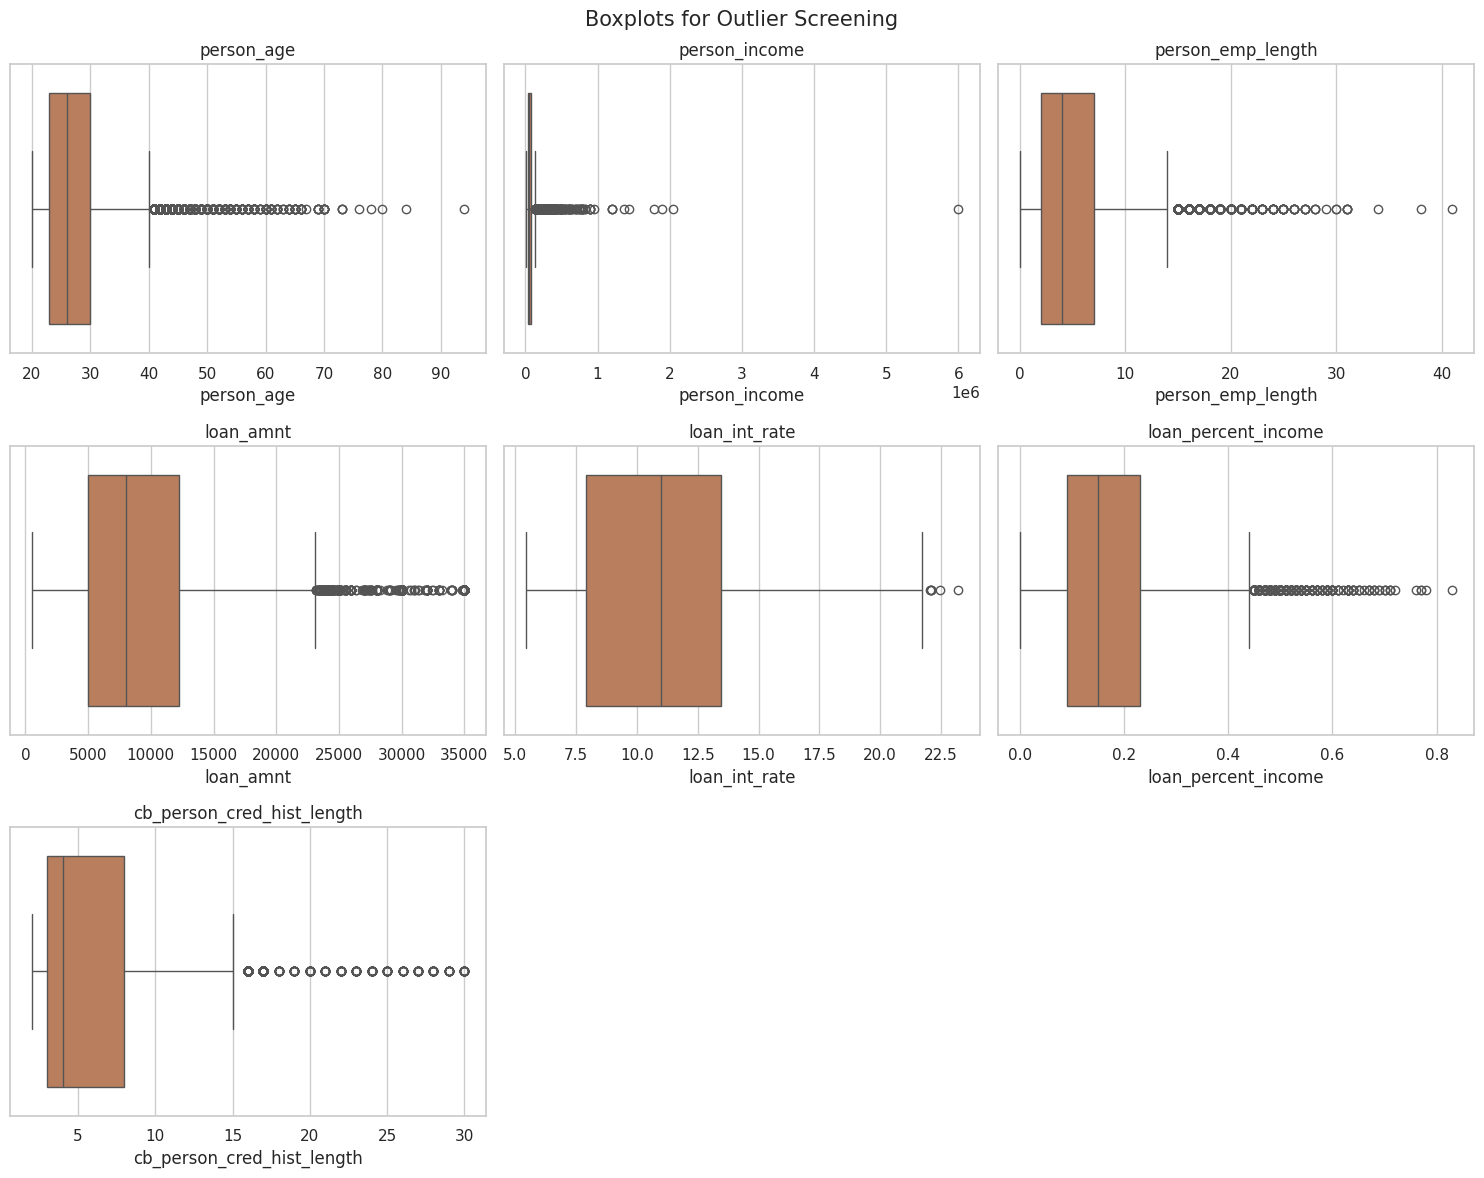

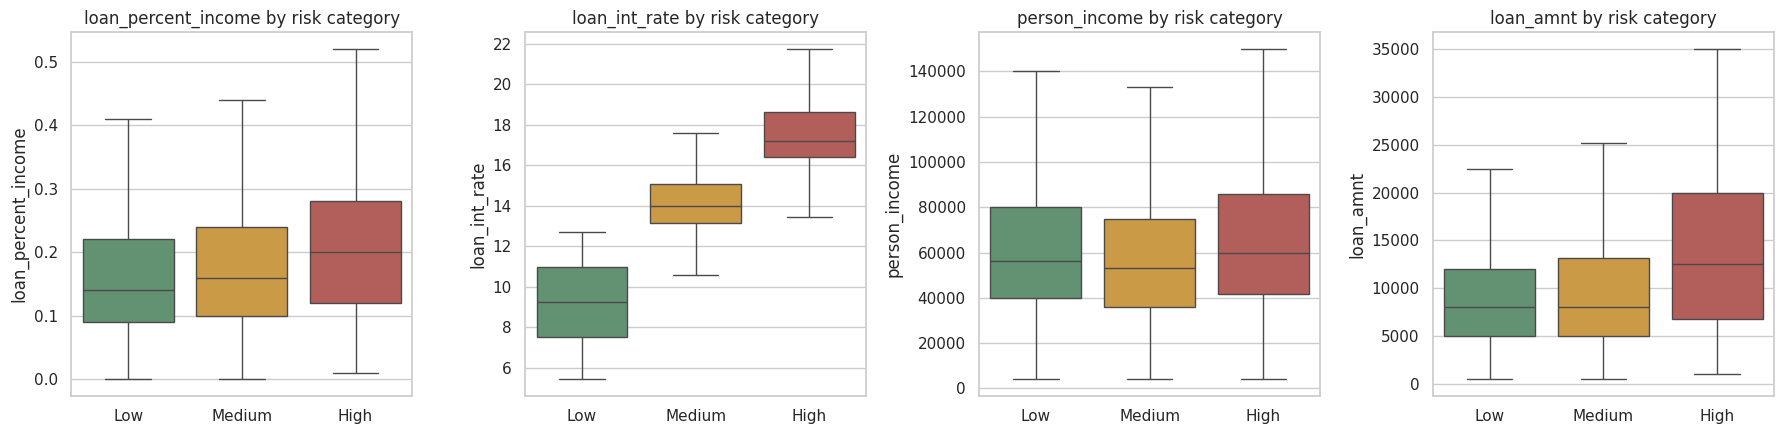

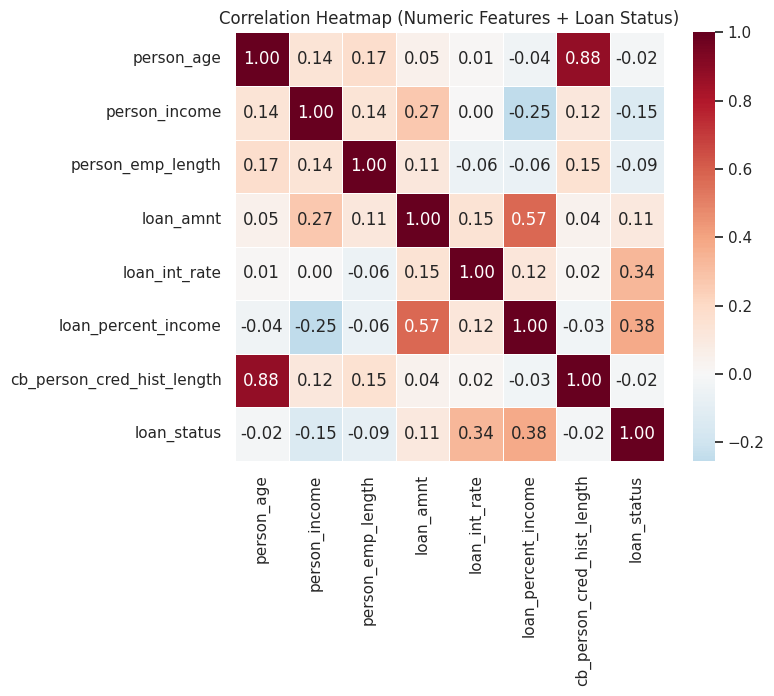

Correlation of each feature with loan_status (default):
loan_percent_income           0.38
loan_int_rate                 0.34
loan_amnt                     0.11
cb_person_cred_hist_length   -0.02
person_age                   -0.02
person_emp_length            -0.09
person_income                -0.15

Key insight: loan_percent_income and loan_int_rate are the strongest applicant-side risk drivers; person_income is a weaker, negative predictor.

4. TRAIN / TEST SPLIT
Features used (10): ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']
Train: 25,932 rows | Test: 6,484 rows (stratified)

5. MODEL TRAINING - MULTINOMIAL LOGISTIC REGRESSION
Using default L2 regularisation strength C = 1.0

6. MODEL EVALUATION (TEST SET)
Test accuracy : 88.6%
Macro F1-score: 0.77
Macro precision: 0.74 | Macro recall: 0.85

Classification report:
          

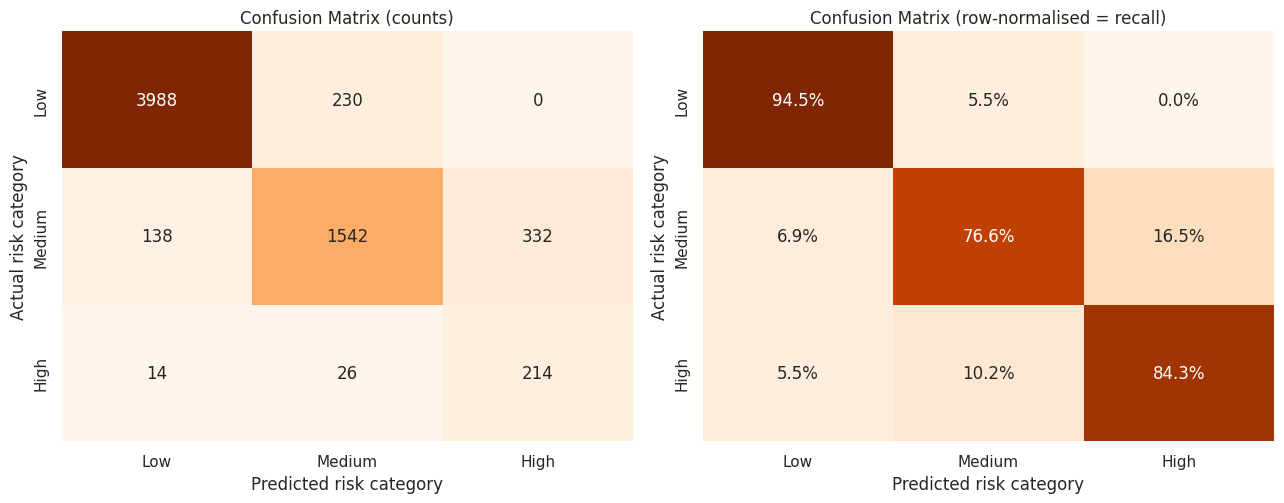

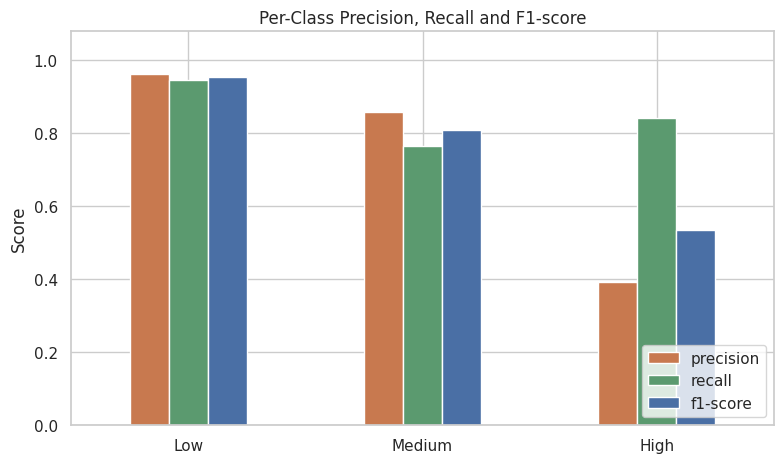


7. MODEL INTERPRETATION - COEFFICIENTS


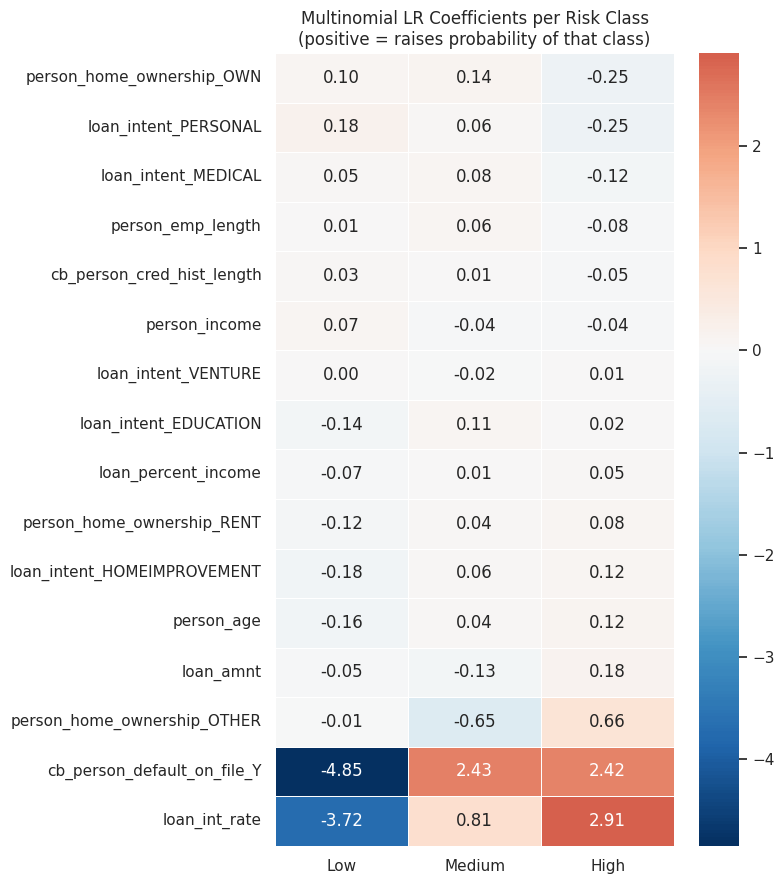

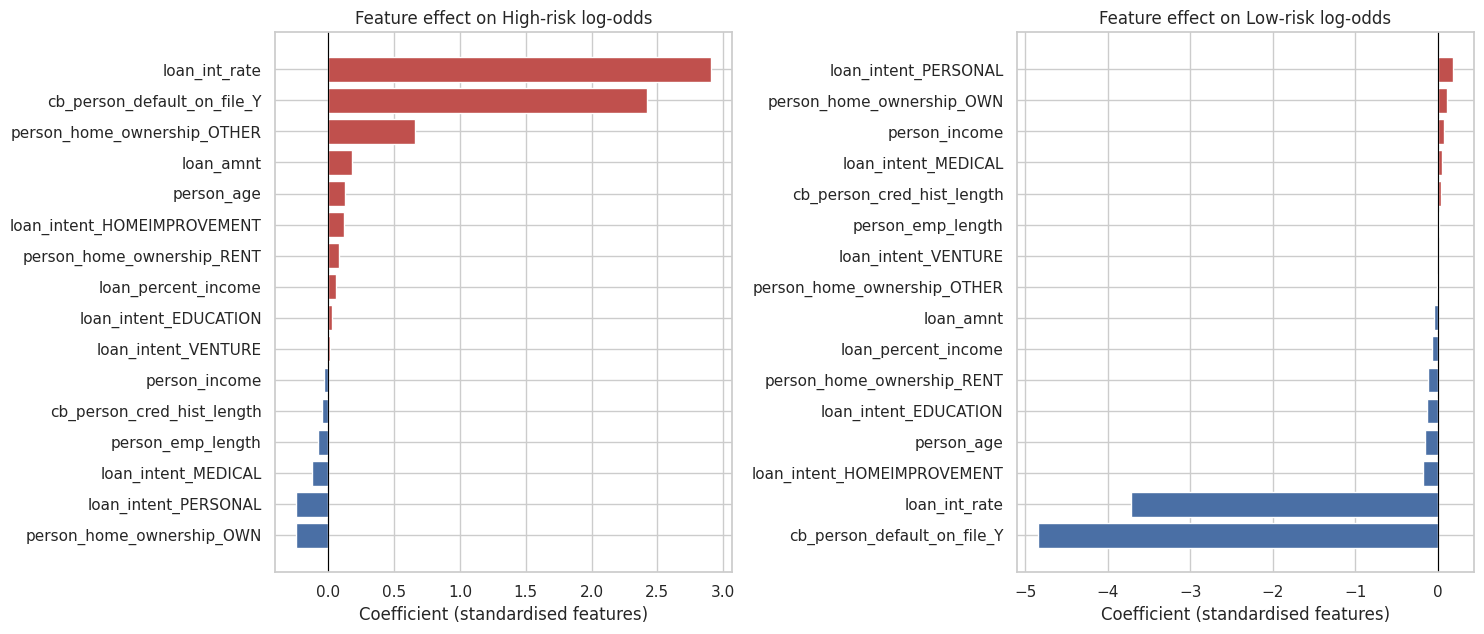

Top features INCREASING High-risk probability:
loan_int_rate                  2.912
cb_person_default_on_file_Y    2.419
person_home_ownership_OTHER    0.658
loan_amnt                      0.179
person_age                     0.125

Top features DECREASING High-risk probability:
person_home_ownership_OWN    -0.248
loan_intent_PERSONAL         -0.246
loan_intent_MEDICAL          -0.123
person_emp_length            -0.078
cb_person_cred_hist_length   -0.045

Odds ratios for High risk (per 1 std-dev / vs. baseline category):
loan_int_rate                  18.396
cb_person_default_on_file_Y    11.238
person_home_ownership_OTHER     1.931
loan_amnt                       1.197
person_age                      1.133
loan_intent_HOMEIMPROVEMENT     1.128
person_home_ownership_RENT      1.084
loan_percent_income             1.055

8. CLASS-PROBABILITY OUTPUT FOR SAMPLE APPLICANTS
       person_income  loan_amnt  loan_int_rate  loan_percent_income cb_person_default_on_file  P(Low)  P(Medium)  P(H

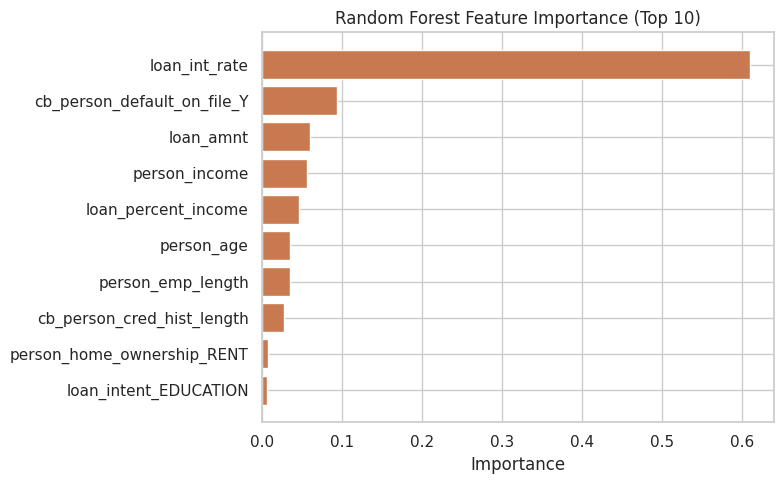

                                 Accuracy  Macro F1
Model                                              
Multinomial Logistic Regression     0.886     0.766
Random Forest                       0.950     0.848

10. SUMMARY
Rows after cleaning : 32,416
Risk split          : Low 65.1% | Medium 31.0% | High 3.9%
Test accuracy       : 88.6%
Macro F1-score      : 0.77
Best C (L2 strength): 1.0
Figures/tables saved in ./outputs/
Done - all charts displayed.


In [ ]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score,
                             precision_score, recall_score)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------------
# Configuration
# ----------------------------------------------------------------------
RANDOM_STATE = 42
TEST_SIZE = 0.20
TUNE_REGULARIZATION = False              # False: default C=1 (matches the PPT: ~88.5%, F1 0.77)
                                         # True : pick C by 5-fold CV (slightly different result)
RUN_RANDOM_FOREST_COMPARISON = True      # "Future scope" slide - set False to skip
OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

sns.set_theme(style="whitegrid")
PALETTE = "#C8794F"                                         # accent colour
RISK_LABELS = ["Low", "Medium", "High"]                     # ordered 0, 1, 2
RISK_COLORS = {"Low": "#5B9A6F", "Medium": "#E0A030", "High": "#C0504D"}

NUMERIC_COLS = [
    "person_age", "person_income", "person_emp_length", "loan_amnt",
    "loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length",
]
CATEGORICAL_COLS = ["person_home_ownership", "loan_intent",
                    "cb_person_default_on_file"]


def save_and_show(name):
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, name), dpi=150, bbox_inches="tight")
    plt.show()


def banner(text):
    print("\n" + "=" * 72 + f"\n{text}\n" + "=" * 72)


# ----------------------------------------------------------------------
# 0. Load the dataset
# ----------------------------------------------------------------------
try:
    import google.colab  # noqa: F401
    from google.colab import files
    print("Running in Google Colab - please upload credit_risk_dataset.csv")
    uploaded = files.upload()
    csv_path = list(uploaded.keys())[0]
except ImportError:
    csv_path = "credit_risk_dataset.csv"

df = pd.read_csv(csv_path)
banner("1. DATASET OVERVIEW")
print(f"Raw dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print("\nMissing values per column:")
print(df.isna().sum()[df.isna().sum() > 0].to_string())

# ----------------------------------------------------------------------
# 1. Data cleaning
# ----------------------------------------------------------------------
n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"\nDuplicates removed: {n_before - len(df):,}")

# Impossible values (e.g. age 144, employment length 123 yrs) -> NaN, then
# imputed with the median inside the pipeline. Rows are kept.
bad_age = df["person_age"] > 100
bad_emp = df["person_emp_length"] > 60
print(f"Impossible ages (>100) set to missing: {bad_age.sum()}")
print(f"Impossible employment lengths (>60) set to missing: {bad_emp.sum()}")
df.loc[bad_age, "person_age"] = np.nan
df.loc[bad_emp, "person_emp_length"] = np.nan

print(f"After cleaning: {df.shape[0]:,} rows x {df.shape[1]} columns")

# ----------------------------------------------------------------------
# 2. Target: Loan Risk Category from loan_grade
# ----------------------------------------------------------------------
def grade_to_risk(g):
    if g in ("A", "B"):
        return "Low"
    if g in ("C", "D"):
        return "Medium"
    return "High"


df["risk_category"] = df["loan_grade"].map(grade_to_risk)
df["risk_code"] = df["risk_category"].map({l: i for i, l in enumerate(RISK_LABELS)})

banner("2. TARGET DISTRIBUTION - LOAN RISK CATEGORY")
dist = (df["risk_category"].value_counts(normalize=True)
        .reindex(RISK_LABELS) * 100).round(1)
for k, v in dist.items():
    print(f"  {k:<7}: {v:5.1f}%   ({(df['risk_category'] == k).sum():,} applicants)")

# ----------------------------------------------------------------------
# 3. EDA
# ----------------------------------------------------------------------
banner("3. EXPLORATORY DATA ANALYSIS")

# 3a. Distribution of risk categories (imbalanced target)
fig, ax = plt.subplots(figsize=(6.5, 4.5))
counts = df["risk_category"].value_counts().reindex(RISK_LABELS)
bars = ax.bar(counts.index, counts.values,
              color=[RISK_COLORS[l] for l in counts.index])
for b, l in zip(bars, counts.index):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
            f"{dist[l]}%\n({counts[l]:,})", ha="center", va="bottom", fontsize=10)
ax.set_ylim(0, counts.max() * 1.18)
ax.set_title("Distribution of Loan Risk Categories")
ax.set_xlabel("Risk category")
ax.set_ylabel("Number of applicants")
save_and_show("01_risk_category_distribution.png")

# 3b. Histograms of numeric features
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(NUMERIC_COLS):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color=PALETTE)
    axes[i].set_title(f"{col}  (skew = {df[col].skew():.2f})")
for j in range(len(NUMERIC_COLS), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle("Distribution of Numeric Features", fontsize=15)
save_and_show("02_numeric_histograms.png")

# 3c. Loan grade counts and default rate by grade
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
grade_order = sorted(df["loan_grade"].unique())
sns.countplot(x="loan_grade", data=df, order=grade_order, color=PALETTE, ax=axes[0])
axes[0].set_title("Applicants by Loan Grade (A = best, G = worst)")
axes[0].set_xlabel("Loan grade")
axes[0].set_ylabel("Count")
grade_default = df.groupby("loan_grade")["loan_status"].mean().sort_index() * 100
sns.barplot(x=grade_default.index, y=grade_default.values, color=PALETTE, ax=axes[1])
axes[1].set_title("Default Rate (%) by Loan Grade")
axes[1].set_xlabel("Loan grade")
axes[1].set_ylabel("Default rate (%)")
save_and_show("03_loan_grade_counts_and_default_rate.png")

# 3d. Categorical features
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for i, col in enumerate(CATEGORICAL_COLS):
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, ax=axes[i], color=PALETTE)
    axes[i].set_title(col)
save_and_show("04_categorical_features.png")

# 3e. Categorical features vs. risk category (stacked, 100 %)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for i, col in enumerate(CATEGORICAL_COLS):
    ct = (pd.crosstab(df[col], df["risk_category"], normalize="index")
          .reindex(columns=RISK_LABELS) * 100)
    ct.plot(kind="barh", stacked=True, ax=axes[i],
            color=[RISK_COLORS[l] for l in RISK_LABELS], legend=(i == 2))
    axes[i].set_title(f"Risk mix by {col}")
    axes[i].set_xlabel("% of applicants")
    axes[i].set_ylabel("")
save_and_show("05_categorical_vs_risk.png")

# 3f. Boxplots for outlier screening
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(NUMERIC_COLS):
    sns.boxplot(x=df[col], ax=axes[i], color=PALETTE)
    axes[i].set_title(col)
for j in range(len(NUMERIC_COLS), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle("Boxplots for Outlier Screening", fontsize=15)
save_and_show("06_boxplots_outliers.png")

# 3g. Numeric features by risk category
key_feats = ["loan_percent_income", "loan_int_rate", "person_income", "loan_amnt"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, col in zip(axes, key_feats):
    sns.boxplot(x="risk_category", y=col, data=df, order=RISK_LABELS,
                palette=RISK_COLORS, ax=ax, showfliers=False)
    ax.set_title(f"{col} by risk category")
    ax.set_xlabel("")
save_and_show("07_key_features_by_risk.png")

# 3h. Correlation heatmap (numeric features + loan_status)
corr = df[NUMERIC_COLS + ["loan_status"]].corr(numeric_only=True)
plt.figure(figsize=(8.5, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5)
plt.title("Correlation Heatmap (Numeric Features + Loan Status)")
save_and_show("08_correlation_heatmap.png")

print("Correlation of each feature with loan_status (default):")
print(corr["loan_status"].drop("loan_status").sort_values(ascending=False)
      .round(2).to_string())
print("\nKey insight: loan_percent_income and loan_int_rate are the strongest "
      "applicant-side risk drivers; person_income is a weaker, negative predictor.")

# ----------------------------------------------------------------------
# 4. Prepare features / target
# ----------------------------------------------------------------------
# loan_grade and loan_status are dropped: the target is derived from loan_grade,
# and loan_status is the outcome itself - keeping either would leak the answer.
X = df.drop(columns=["loan_grade", "loan_status", "risk_category", "risk_code"])
y = df["risk_code"]

banner("4. TRAIN / TEST SPLIT")
print(f"Features used ({X.shape[1]}): {list(X.columns)}")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)
print(f"Train: {len(X_train):,} rows | Test: {len(X_test):,} rows (stratified)")

preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), NUMERIC_COLS),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), CATEGORICAL_COLS),
])

# ----------------------------------------------------------------------
# 5. Multinomial Logistic Regression (L2-regularised, optional C tuning)
# ----------------------------------------------------------------------
# With the lbfgs solver, scikit-learn fits a true multinomial (softmax) model
# for multi-class targets. class_weight="balanced" handles the 3.9 % High class.
banner("5. MODEL TRAINING - MULTINOMIAL LOGISTIC REGRESSION")
pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(solver="lbfgs", max_iter=2000,
                               class_weight="balanced", random_state=RANDOM_STATE)),
])
if TUNE_REGULARIZATION:
    grid = GridSearchCV(
        pipe,
        param_grid={"clf__C": [0.01, 0.1, 1, 10, 100]},      # C = 1 / regularisation
        scoring="f1_macro",
        cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
        n_jobs=-1,
    )
    grid.fit(X_train, y_train)
    model = grid.best_estimator_
    best_C = grid.best_params_["clf__C"]
    print(f"Best regularisation strength C = {best_C}  "
          f"(5-fold CV macro-F1 = {grid.best_score_:.3f})")
else:
    model = pipe.fit(X_train, y_train)
    best_C = model.named_steps["clf"].C
    print(f"Using default L2 regularisation strength C = {best_C}")

# ----------------------------------------------------------------------
# 6. Evaluation
# ----------------------------------------------------------------------
banner("6. MODEL EVALUATION (TEST SET)")
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
print(f"Test accuracy : {acc * 100:.1f}%")
print(f"Macro F1-score: {macro_f1:.2f}")
print(f"Macro precision: {precision_score(y_test, y_pred, average='macro'):.2f} | "
      f"Macro recall: {recall_score(y_test, y_pred, average='macro'):.2f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=RISK_LABELS, digits=3))

cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
cm_norm = cm / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", cbar=False,
            xticklabels=RISK_LABELS, yticklabels=RISK_LABELS, ax=axes[0])
axes[0].set_title("Confusion Matrix (counts)")
sns.heatmap(cm_norm, annot=True, fmt=".1%", cmap="Oranges", cbar=False,
            xticklabels=RISK_LABELS, yticklabels=RISK_LABELS, ax=axes[1])
axes[1].set_title("Confusion Matrix (row-normalised = recall)")
for ax in axes:
    ax.set_xlabel("Predicted risk category")
    ax.set_ylabel("Actual risk category")
save_and_show("09_confusion_matrix.png")

# Per-class precision / recall / F1 chart
rep = classification_report(y_test, y_pred, target_names=RISK_LABELS, output_dict=True)
metrics_df = pd.DataFrame({k: rep[k] for k in RISK_LABELS}).T[["precision", "recall", "f1-score"]]
metrics_df.plot(kind="bar", figsize=(8, 4.8), rot=0,
                color=["#C8794F", "#5B9A6F", "#4A6FA5"])
plt.ylim(0, 1.08)
plt.title("Per-Class Precision, Recall and F1-score")
plt.ylabel("Score")
plt.legend(loc="lower right")
save_and_show("10_per_class_metrics.png")

# ----------------------------------------------------------------------
# 7. Interpretation - model coefficients
# ----------------------------------------------------------------------
banner("7. MODEL INTERPRETATION - COEFFICIENTS")
feat_names = [n.replace("num__", "").replace("cat__", "")
              for n in model.named_steps["prep"].get_feature_names_out()]
coefs = pd.DataFrame(model.named_steps["clf"].coef_,
                     index=RISK_LABELS, columns=feat_names).T

# Heatmap of all coefficients (rows sorted by effect on High risk)
order = coefs["High"].sort_values().index
plt.figure(figsize=(8, 9))
sns.heatmap(coefs.loc[order], annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=0.4)
plt.title("Multinomial LR Coefficients per Risk Class\n"
          "(positive = raises probability of that class)")
save_and_show("11_coefficients_heatmap.png")

# Bar chart: what drives HIGH vs LOW risk
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
for ax, cls in zip(axes, ["High", "Low"]):
    s = coefs[cls].sort_values()
    ax.barh(s.index, s.values, color=[RISK_COLORS["High"] if v > 0 else "#4A6FA5" for v in s.values])
    ax.axvline(0, color="black", lw=0.8)
    ax.set_title(f"Feature effect on {cls}-risk log-odds")
    ax.set_xlabel("Coefficient (standardised features)")
save_and_show("12_coefficients_high_vs_low.png")

print("Top features INCREASING High-risk probability:")
print(coefs["High"].sort_values(ascending=False).head(5).round(3).to_string())
print("\nTop features DECREASING High-risk probability:")
print(coefs["High"].sort_values().head(5).round(3).to_string())

odds = np.exp(coefs["High"]).sort_values(ascending=False).round(3)
print("\nOdds ratios for High risk (per 1 std-dev / vs. baseline category):")
print(odds.head(8).to_string())

# ----------------------------------------------------------------------
# 8. Probability output for individual applicants
# ----------------------------------------------------------------------
banner("8. CLASS-PROBABILITY OUTPUT FOR SAMPLE APPLICANTS")
sample_idx = (list(y_test[y_test == 0].index[:2]) + list(y_test[y_test == 1].index[:2])
              + list(y_test[y_test == 2].index[:2]))
sample = X.loc[sample_idx]
proba = model.predict_proba(sample)
out = sample[["person_income", "loan_amnt", "loan_int_rate",
              "loan_percent_income", "cb_person_default_on_file"]].copy()
for i, lbl in enumerate(RISK_LABELS):
    out[f"P({lbl})"] = (proba[:, i] * 100).round(1)
out["Predicted"] = [RISK_LABELS[k] for k in model.predict(sample)]
out["Actual"] = [RISK_LABELS[k] for k in y.loc[sample_idx]]
print(out.to_string())
out.to_csv(os.path.join(OUT_DIR, "sample_predictions.csv"))

# ----------------------------------------------------------------------
# 9. Future scope (optional): compare with Random Forest
# ----------------------------------------------------------------------
comparison = [{"Model": "Multinomial Logistic Regression",
               "Accuracy": acc, "Macro F1": macro_f1}]
if RUN_RANDOM_FOREST_COMPARISON:
    banner("9. FUTURE SCOPE - COMPARISON WITH RANDOM FOREST")
    rf = Pipeline([
        ("prep", preprocessor),
        ("clf", RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                       n_jobs=-1, random_state=RANDOM_STATE)),
    ]).fit(X_train, y_train)
    rf_pred = rf.predict(X_test)
    comparison.append({"Model": "Random Forest",
                       "Accuracy": accuracy_score(y_test, rf_pred),
                       "Macro F1": f1_score(y_test, rf_pred, average="macro")})

    # Feature importance (Random Forest)
    imp = pd.Series(rf.named_steps["clf"].feature_importances_,
                    index=[n.replace("num__", "").replace("cat__", "")
                           for n in rf.named_steps["prep"].get_feature_names_out()]
                    ).sort_values().tail(10)
    plt.figure(figsize=(8, 5))
    plt.barh(imp.index, imp.values, color=PALETTE)
    plt.title("Random Forest Feature Importance (Top 10)")
    plt.xlabel("Importance")
    save_and_show("13_rf_feature_importance.png")

comp_df = pd.DataFrame(comparison).set_index("Model").round(3)
print(comp_df.to_string())

# ----------------------------------------------------------------------
# 10. Save summary
# ----------------------------------------------------------------------
banner("10. SUMMARY")
print(f"Rows after cleaning : {len(df):,}")
print(f"Risk split          : Low {dist['Low']}% | Medium {dist['Medium']}% | High {dist['High']}%")
print(f"Test accuracy       : {acc * 100:.1f}%")
print(f"Macro F1-score      : {macro_f1:.2f}")
print(f"Best C (L2 strength): {best_C}")
print(f"Figures/tables saved in ./{OUT_DIR}/")

coefs.round(4).to_csv(os.path.join(OUT_DIR, "model_coefficients.csv"))
comp_df.to_csv(os.path.join(OUT_DIR, "model_comparison.csv"))
metrics_df.round(4).to_csv(os.path.join(OUT_DIR, "per_class_metrics.csv"))
print("Done - all charts displayed.")